In [15]:
'''
problem statement - titanic survival prediction based on passenger details
- Classification report
- confusion matrix
- improve the performance of the model
'''

# required lib
! pip install pandas scikit-learn matplotlib seaborn
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
# load the dataset
titanic_dataset=pd.read_csv('train.csv')
titanic_dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [19]:
# Data Preprocessing
# handle missing values

titanic_dataset.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [20]:
# fill the missing values
titanic_dataset['Embarked'].fillna(titanic_dataset['Embarked'].mode()[0])

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object

In [21]:
titanic_dataset['Age'].fillna(titanic_dataset['Age'].median(),inplace=True)
titanic_dataset['Embarked'].fillna(titanic_dataset['Embarked'].mode()[0],inplace=True)
titanic_dataset.drop(columns=['Cabin'],inplace=True)


C:\Users\Johnpaul.a\AppData\Local\Temp\ipykernel_25404\2927493283.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_dataset['Age'].fillna(titanic_dataset['Age'].median(),inplace=True)
C:\Users\Johnpaul.a\AppData\Local\Temp\ipykernel_25404\2927493283.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting valu

In [22]:
titanic_dataset.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [23]:
# segregate features and target  i.e X and Y

X=titanic_dataset[['Pclass','Sex','Age','SibSp','Parch','Embarked']]
Y=titanic_dataset['Survived']

In [24]:
# Encoding in X

# Label Encoder

label_encoder=LabelEncoder()
X['Sex']=label_encoder.fit_transform(X['Sex'])


C:\Users\Johnpaul.a\AppData\Local\Temp\ipykernel_25404\1501507728.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Sex']=label_encoder.fit_transform(X['Sex'])


In [25]:
X

,Pclass,Sex,Age,SibSp,Parch,Embarked
0,3,1,22.0,1,0,S
1,1,0,38.0,1,0,C
2,3,0,26.0,0,0,S
3,1,0,35.0,1,0,S
4,3,1,35.0,0,0,S
...,...,...,...,...,...,...
886,2,1,27.0,0,0,S
887,1,0,19.0,0,0,S
888,3,0,28.0,1,2,S
889,1,1,26.0,0,0,C


In [26]:
X=pd.get_dummies(X,columns=['Embarked'],prefix='Embarked')

In [27]:
X

,Pclass,Sex,Age,SibSp,Parch,Embarked_C,Embarked_Q,Embarked_S
0,3,1,22.0,1,0,False,False,True
1,1,0,38.0,1,0,True,False,False
2,3,0,26.0,0,0,False,False,True
3,1,0,35.0,1,0,False,False,True
4,3,1,35.0,0,0,False,False,True
...,...,...,...,...,...,...,...,...
886,2,1,27.0,0,0,False,False,True
887,1,0,19.0,0,0,False,False,True
888,3,0,28.0,1,2,False,False,True
889,1,1,26.0,0,0,True,False,False


In [29]:
# Spilt traing and test data

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [ ]:
model=RandomForestClassifier(random_state=42)
model.fit(X_train,Y_train)
print("Base Accuracy",model.score(X_test,Y_test))

Base Accuracy 0.8100558659217877


In [37]:
model.fit(X_train,Y_train)
y_pred=model.predict(X_test)
accuracy_score(Y_test,y_pred)


0.8100558659217877

In [35]:
# To improve performance of this model - Fine tunning - Hyperparameter tunning

# GridsearchCV

from sklearn.model_selection import GridSearchCV

param_grid={
    'n_estimators':[100,200],
    'max_depth':[4,6,8],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}

grid_search=GridSearchCV(RandomForestClassifier(random_state=42),param_grid,cv=5,scoring='accuracy')
grid_search.fit(X_train,Y_train)

print("Best Parameter",grid_search.best_params_)
print("Best CV acccuracy",grid_search.best_score_)


Best Parameter {'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV acccuracy 0.8300502314586822


In [38]:
best_model=grid_search.best_estimator_
from sklearn.metrics import classification_report
y_pred=best_model.predict(X_test)
print(classification_report(Y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.90      0.85       105
           1       0.83      0.68      0.75        74

    accuracy                           0.81       179
   macro avg       0.82      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



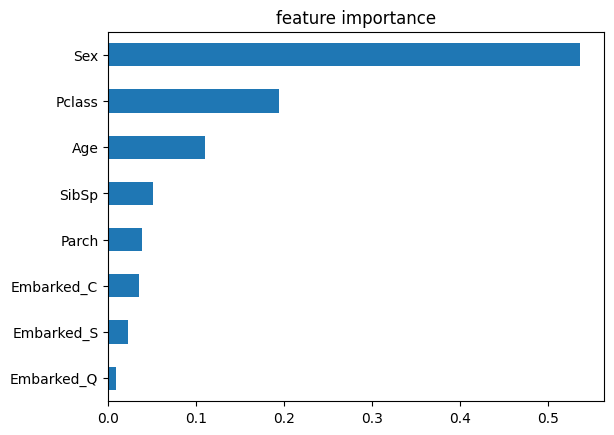

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
feature_importances=pd.Series(best_model.feature_importances_,index=X.columns)
feature_importances.sort_values().plot(kind='barh')
plt.title("feature importance")
plt.show()

In [51]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist={
    'n_estimators':randint(100,500),
    'max_depth':randint(3,10),
    'min_samples_split':randint(2,10)
}

random_search=RandomizedSearchCV(RandomForestClassifier(),param_distributions=param_dist,n_iter=20,cv=5)
random_search.fit(X_train,Y_train)

print("Best Parameters",random_search.best_params_)
print("Best CV accuracy",random_search.best_score_)

Best Parameters {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 397}
Best CV accuracy 0.8286516300600809


In [47]:
! pip install optuna

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
! pip install optuna
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    clf = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 500),
        max_depth=trial.suggest_int("max_depth", 3, 15),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 10)
    )
    return cross_val_score(clf, X_train, Y_train, cv=5).mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)
print(study.best_params)

[I 2025-05-13 12:51:07,151] A new study created in memory with name: no-name-8e68be5b-903c-4aa8-a067-b5aa2da6cb5d

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


[I 2025-05-13 12:51:08,426] Trial 0 finished with value: 0.8174234216487738 and parameters: {'n_estimators': 122, 'max_depth': 6, 'min_samples_split': 2}. Best is trial 0 with value: 0.8174234216487738.
[I 2025-05-13 12:51:10,516] Trial 1 finished with value: 0.8230276765488034 and parameters: {'n_estimators': 252, 'max_depth': 5, 'min_samples_split': 10}. Best is trial 1 with value: 0.8230276765488034.
[I 2025-05-13 12:51:12,270] Trial 2 finished with value: 0.8117699202206244 and parameters: {'n_estimators': 183, 'max_depth': 14, 'min_samples_split': 8}. Best is trial 1 with value: 0.8230276765488034.
[I 2025-05-13 12:51:16,662] Trial 3 finished with value: 0.8019797104304146 and parameters: {'n_estimators': 467, 'max_depth': 10, 'min_samples_split': 3}. Best is trial 1 with value: 0.8230276765488034.
[I 2025-05-13 12:51:18,269] Trial 4 finished with value: 0.8005515611149414 and parameters: {'n_estimators': 171, 'max_depth': 14, 'min_samples_split': 3}. Best is trial 1 with value: 0